#Assignment 1. Digital Signal Processing

##Implementing a PyTorch layer for extraction of logarithms of Mel-scale Filterbank energies using basic torch math operations

In [1]:
import torchaudio
from torchaudio.datasets import SPEECHCOMMANDS

import torch
from typing import Optional

from torch import nn
from torchaudio import functional as F

import matplotlib.pyplot as plt

In [2]:
dataset = SPEECHCOMMANDS(root="./", download=True)


100%|██████████| 2.26G/2.26G [00:26<00:00, 92.6MB/s]


In [3]:
yes_sample = next(sample for sample in dataset if sample[2] == "yes")

In [4]:
signal, sr = yes_sample[0], yes_sample[1]
signal = signal.squeeze(0).unsqueeze(0)


###Implementation

In [5]:
class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()
        # general params and params defined by the exercise
        self.n_fft = n_fft
        self.samplerate = samplerate
        self.window_length = n_fft
        self.register_buffer("window", torch.hann_window(self.window_length))
        # Do correct initialization of stft params below:
        # hop_length, n_mels, center, return_complex, onesided, normalize_stft, pad_mode, power
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.center = center
        self.return_complex = return_complex
        self.onesided = onesided
        self.normalize_stft = normalize_stft
        self.pad_mode = pad_mode
        self.power = power

        # Do correct initialization of mel fbanks params below:
        # f_min_hz, f_max_hz, norm_mel, mel_scale
        self.f_min_hz = f_min_hz
        self.f_max_hz = f_max_hz
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale

        # finish parameters initialization
        self.mel_fbanks = self._init_melscale_fbanks()

    def _init_melscale_fbanks(self):
        # To access attributes, use self.<parameter_name>
        return F.melscale_fbanks(
            # Turns a normal STFT into a mel frequency STFT with triangular filter banks
            # make a full and correct function call
            n_freqs=self.n_fft // 2 + 1,
            f_min = self.f_min_hz,
            f_max = self.samplerate // 2 if self.f_max_hz is None else self.f_max_hz,
            n_mels = self.n_mels,
            sample_rate = self.samplerate,
            norm = self.norm_mel,
            mel_scale = self.mel_scale,
        )

    def spectrogram(self, x):
      specs = []
      for sample in x:
        spec =  torch.stft(
            input = sample,
            n_fft=self.n_fft,
            hop_length = self.hop_length,
            win_length = self.window_length,
            window = self.window,
            center = self.center,
            pad_mode = self.pad_mode,
            return_complex = self.return_complex,
            onesided = self.onesided,
            normalized = self.normalize_stft,
        )
        power_spec = spec.abs() ** self.power
        specs.append(power_spec)
      return torch.stack(specs)


# make a full and correct function call

    def forward(self, x):
        """
        Args:
            x (Torch.Tensor): Tensor of audio of dimension (batch, time), audiosignal
        Returns:
            Torch.Tensor: Tensor of log mel filterbanks of dimension (batch, n_mels, n_frames),
                where n_frames is a function of the window_length, hop_length and length of audio
        """
        spec = self.spectrogram(x)
        spec = spec.transpose(1, 2)
        mel_spec = torch.matmul(spec, self.mel_fbanks)
        mel_spec = mel_spec.transpose(1, 2)

        log_mel = torch.log(mel_spec + 1e-6)

        # Return log mel filterbanks matrix
        return log_mel

In [6]:
logmel = LogMelFilterBanks()(signal)

print(logmel.shape)  # (batch, n_mels, n_frames)


torch.Size([1, 80, 101])


###Evaluation

In [7]:
melspec = torchaudio.transforms.MelSpectrogram(
    hop_length=160,
    n_mels=80
)(signal)
logmelbanks = LogMelFilterBanks()(signal)

assert torch.log(melspec + 1e-6).shape == logmelbanks.shape
assert torch.allclose(torch.log(melspec + 1e-6), logmelbanks)

plots

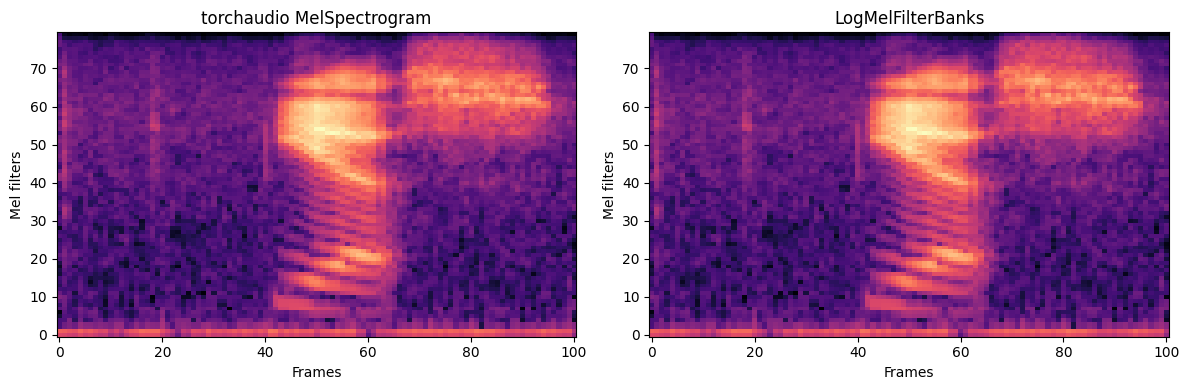

In [8]:
log_melspec = torch.log(melspec + 1e-6).squeeze(0).numpy()
log_logmelbanks = logmelbanks.squeeze(0).numpy()

plt.figure(figsize=(12, 4))

# torchaudio MelSpectrogram
plt.subplot(1, 2, 1)
plt.imshow(log_melspec, origin="lower", aspect="auto", cmap="magma")
plt.title("torchaudio MelSpectrogram")
plt.xlabel("Frames")
plt.ylabel("Mel filters")

# my function
plt.subplot(1, 2, 2)
plt.imshow(log_logmelbanks, origin="lower", aspect="auto", cmap="magma")
plt.title("LogMelFilterBanks")
plt.xlabel("Frames")
plt.ylabel("Mel filters")

plt.tight_layout()
plt.show()


well, it seems working (: